In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 65.0 MB/s eta 0:00:00


In [ ]:
# Import library
import os, json, random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from gensim.models import Word2Vec

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Set random seed and device
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# Load saved data and vocabulary
data_root = r"/content/gdrive/MyDrive/Colab Notebooks"
artifacts_dir = os.path.join(data_root, "imdb_artifacts")

print("Loading vocabulary and data...")
with open(os.path.join(artifacts_dir, "vocab.json"), "r", encoding="utf-8") as f:
    vocab = json.load(f)

PAD_ID = vocab["<PAD>"]
UNK_ID = vocab["<UNK>"]
vocab_size = len(vocab)
id2word = {int(idx): word for word, idx in vocab.items()}

train_ids, train_labels = torch.load(os.path.join(artifacts_dir, "train_dataset.pt"))
val_ids, val_labels = torch.load(os.path.join(artifacts_dir, "val_dataset.pt"))
test_ids, test_labels = torch.load(os.path.join(artifacts_dir, "test_dataset.pt"))

print(f"Vocabulary size: {vocab_size}")
print(f"Training set: {len(train_ids)} samples")
print(f"Validation set: {len(val_ids)} samples")
print(f"Test set: {len(test_ids)} samples")
print(f"PAD_ID: {PAD_ID}, UNK_ID: {UNK_ID}")

Loading vocabulary and data...
Vocabulary size: 28083
Training set: 17499 samples
Validation set: 3751 samples
Test set: 3750 samples
PAD_ID: 0, UNK_ID: 1


In [ ]:
# Check some sample information
print("Length of first 3 training samples:", [len(seq) for seq in train_ids[:3]])
print("Training set label distribution:", np.bincount(train_labels))
print("Validation set label distribution:", np.bincount(val_labels))
print("Test set label distribution:", np.bincount(test_labels))

Length of first 3 training samples: [58, 89, 94]
Training set label distribution: [8749 8750]
Validation set label distribution: [1876 1875]
Test set label distribution: [1875 1875]


In [ ]:
# Dataset and DataLoader
class IMDBVarLenDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels
    def __len__(self):
        return len(self.sequences)
    def __getitem__(self, idx):
        return torch.tensor(self.sequences[idx], dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

def collate_fn(batch, pad_id=PAD_ID):
    seqs, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    padded = torch.nn.utils.rnn.pad_sequence(seqs, batch_first=True, padding_value=pad_id)
    mask = (padded != pad_id).long()
    labels = torch.stack(labels)
    return padded, labels, lengths, mask

batch_size = 64
train_dataset = IMDBVarLenDataset(train_ids, train_labels)
val_dataset = IMDBVarLenDataset(val_ids, val_labels)
test_dataset = IMDBVarLenDataset(test_ids, test_labels)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          collate_fn=lambda b: collate_fn(b, pad_id=PAD_ID))
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        collate_fn=lambda b: collate_fn(b, pad_id=PAD_ID))
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                         collate_fn=lambda b: collate_fn(b, pad_id=PAD_ID))

print(f"Batch size: {batch_size}")
print(f"Number of training batches: {len(train_loader)}")

Batch size: 64
Number of training batches: 274


In [ ]:
# Check one batch of data
for batch_idx, (padded, labels, lengths, mask) in enumerate(train_loader):
    if batch_idx == 0:
        print(f"First batch shapes:")
        print(f"Padded sequences: {padded.shape}")
        print(f"Labels: {labels.shape}")
        print(f"Sequence lengths: {lengths[:10]}...")  # Show first 10 sequence lengths
        print(f"Mask: {mask.shape}")
        break

First batch shapes:
Padded sequences: torch.Size([64, 364])
Labels: torch.Size([64])
Sequence lengths: tensor([ 90, 106,  79, 116,  57,  52,  71,  93,  80, 108])...
Mask: torch.Size([64, 364])


In [ ]:
# Train Word2Vec word embeddings
train_texts_words = [[id2word.get(idx, "<UNK>") for idx in seq] for seq in train_ids]

# Check some text samples
print("Original ID sequence example:", train_ids[0][:10])
print("Corresponding word example:", train_texts_words[0][:10])

w2v_dim = 100
print(f"Starting Word2Vec model training, embedding dimension: {w2v_dim}")
w2v_model = Word2Vec(sentences=train_texts_words, vector_size=w2v_dim, window=5, min_count=1, workers=4, seed=SEED)

print(f"Top 10 most frequent words in vocabulary: {list(vocab.keys())[:10]}")

# Test word embeddings
test_word = "the"
if test_word in w2v_model.wv:
    print(f"Word vector shape for '{test_word}': {w2v_model.wv[test_word].shape}")
    print(f"Most similar words to '{test_word}': {w2v_model.wv.most_similar(test_word, topn=3)}")

# Create embedding matrix
embedding_matrix = np.zeros((vocab_size, w2v_dim))
found_count = 0
for word, idx in vocab.items():
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
        found_count += 1
    else:
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=(w2v_dim,))

embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float32)
print(f"Embedding matrix shape: {embedding_matrix.shape}")
print(f"Word vectors found in vocabulary: {found_count}/{vocab_size} ({found_count/vocab_size*100:.2f}%)")

Original ID sequence example: [1321, 218, 4, 3846, 236, 15, 1464, 11628, 3827, 1474]
Corresponding word example: ['critic', 'found', 'film', 'bleak', 'enough', 'good', 'humour', 'optimism', 'overcome', 'impression']
Starting Word2Vec model training, embedding dimension: 100
Top 10 most frequent words in vocabulary: ['<PAD>', '<UNK>', 'NOT_the', 'movie', 'film', "n't", 'NOT_to', 'NOT_a', 'one', 'NOT_of']
Embedding matrix shape: torch.Size([28083, 100])
Word vectors found in vocabulary: 28079/28083 (99.99%)


In [ ]:
# Define LSTM model
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=10, dropout=0.5, embedding_weights=None, trainable=True, batch_norm=True):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(embedding_weights, freeze=not trainable, padding_idx=PAD_ID)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout)

        self.batch_norm = nn.BatchNorm1d(hidden_dim) if batch_norm else None
        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, (hn, cn) = self.lstm(packed)
        out = hn[-1]

        if self.batch_norm:
            out = out.unsqueeze(0)
            out = self.batch_norm(out.squeeze(0))

        out = self.dropout(out)

        logits = self.fc(out)
        return logits.squeeze(1)

In [ ]:
# Define training and evaluation functions
def train_model(model, train_loader, val_loader, name, epochs=3, lr=0.001, patience=7, clip_grad_norm=5, scaler=None):
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2)

    best_f1 = 0
    patience_counter = 0

    # Initialize mixed precision
    if scaler is None:
        scaler = GradScaler()

    history = []

    print(f"Starting training for {epochs} epochs")

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        batch_count = 0

        for x, y, lengths, mask in train_loader:
            x, y, lengths = x.to(device), y.float().to(device), lengths.to(device)

            # Zero gradients
            optimizer.zero_grad()

            # Mixed precision training
            with autocast():  # Enable mixed precision
                logits = model(x, lengths)
                loss = criterion(logits, y)

            # Backward propagation
            scaler.scale(loss).backward()

            # Gradient clipping to prevent gradient explosion
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)

            # Update parameters
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item() * x.size(0)
            batch_count += 1

        avg_loss = total_loss / len(train_loader.dataset)

        # Validate model and calculate metrics
        acc, prec, rec, f1 = evaluate_model(model, val_loader)

        history.append({
            'epoch': epoch + 1,
            'loss': avg_loss,
            'val_acc': acc,
            'val_prec': prec,
            'val_rec': rec,
            'val_f1': f1
        })

        print(f"{epoch+1}/{epochs}")


        print(f"Epoch {epoch + 1}/{epochs}: Loss={avg_loss:.4f}, Val Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}")

        # Learning rate adjustment
        scheduler.step(avg_loss)  # Dynamically adjust learning rate based on validation loss

        # Early stopping logic
        if f1 > best_f1:
            best_f1 = f1
            patience_counter = 0  # Reset patience counter
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered!")
            break

    history_df = pd.DataFrame(history)
    history_df.to_csv(f'{name}_training_history.csv', index=False)
    print("Training history saved to file")

    return model

# Define evaluation function
def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y, lengths, mask in loader:
            x, y, lengths = x.to(device), y.to(device), lengths.to(device)
            logits = model(x, lengths)
            preds = torch.sigmoid(logits) >= 0.5
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    return acc, prec, rec, f1

# Weight initialization function
def initialize_weights(model):
    for name, param in model.named_parameters():
        if 'weight' in name:
            if isinstance(param, nn.Linear):
                nn.init.xavier_normal_(param.data)  # Xavier
            elif isinstance(param, nn.LSTM):
                nn.init.kaiming_normal_(param.data)  # Kaiming
        elif 'bias' in name:
            nn.init.zeros_(param.data)  # Initialize bias to zero

print("Training and evaluation functions defined successfully!")

Training and evaluation functions defined successfully!


In [ ]:
# Define training and evaluation functions
def train_model_without_early(model, train_loader, val_loader, name, epochs=3, lr=0.001, patience=7, clip_grad_norm=5, scaler=None):
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2)

    best_f1 = 0
    patience_counter = 0

    # Initialize mixed precision
    if scaler is None:
        scaler = GradScaler()

    history = []

    print(f"Starting training for {epochs} epochs")

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        batch_count = 0

        for x, y, lengths, mask in train_loader:
            x, y, lengths = x.to(device), y.float().to(device), lengths.to(device)

            # Zero gradients
            optimizer.zero_grad()

            # Mixed precision training
            with autocast():  # Enable mixed precision
                logits = model(x, lengths)
                loss = criterion(logits, y)

            # Backward propagation
            scaler.scale(loss).backward()

            # Gradient clipping to prevent gradient explosion
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)

            # Update parameters
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item() * x.size(0)
            batch_count += 1

        avg_loss = total_loss / len(train_loader.dataset)

        # Validate model and calculate metrics
        acc, prec, rec, f1 = evaluate_model(model, val_loader)

        history.append({
            'epoch': epoch + 1,
            'loss': avg_loss,
            'val_acc': acc,
            'val_prec': prec,
            'val_rec': rec,
            'val_f1': f1
        })

        print(f"{epoch+1}/{epochs}")

        print(f"Epoch {epoch + 1}/{epochs}: Loss={avg_loss:.4f}, Val Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}")

        # Learning rate adjustment
        scheduler.step(avg_loss)  # Dynamically adjust learning rate based on validation loss

    history_df = pd.DataFrame(history)
    history_df.to_csv(f'{name}_training_history2.csv', index=False)
    print("Training history saved to file")

    return model

# Define evaluation function
def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y, lengths, mask in loader:
            x, y, lengths = x.to(device), y.to(device), lengths.to(device)
            logits = model(x, lengths)
            preds = torch.sigmoid(logits) >= 0.5
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    return acc, prec, rec, f1

# Weight initialization function
def initialize_weights(model):
    for name, param in model.named_parameters():
        if 'weight' in name:
            if isinstance(param, nn.Linear):
                nn.init.xavier_normal_(param.data)  # Xavier
            elif isinstance(param, nn.LSTM):
                nn.init.kaiming_normal_(param.data)  # Kaiming
        elif 'bias' in name:
            nn.init.zeros_(param.data)  # Initialize bias to zero

print("Training and evaluation functions defined successfully!")

Training and evaluation functions defined successfully!


In [ ]:
# Word2Vec Frozen
hidden_dim = 128
print("=" * 50)
print("Experiment 1: Word2Vec Frozen")
print("=" * 50)

model_w2v_freeze = LSTMClassifier(vocab_size, embed_dim=w2v_dim, hidden_dim=hidden_dim,
                                  dropout=0.5, embedding_weights=embedding_matrix, trainable=False)

initialize_weights(model_w2v_freeze)

print(f"Model parameters:")
print(f"- Vocabulary size: {vocab_size}")
print(f"- Word embedding dimension: {w2v_dim}")
print(f"- LSTM hidden dimension: {hidden_dim}")
print(f"- Embedding layer trainable: False")

total_params = sum(p.numel() for p in model_w2v_freeze.parameters() if p.requires_grad)
print(f"- Trainable parameter count: {total_params:,}")

model_w2v_freeze = train_model(model_w2v_freeze, train_loader, val_loader, name='freeze', epochs=50, lr=0.001)

Experiment 1: Word2Vec Frozen
Model parameters:
- Vocabulary size: 28083
- Word embedding dimension: 100
- LSTM hidden dimension: 128
- Embedding layer trainable: False
- Trainable parameter count: 1,307,009
Starting training for 50 epochs
1/50
Epoch 1/50: Loss=0.6081, Val Acc=0.5905, Prec=0.5505, Rec=0.9851, F1=0.7063
2/50
Epoch 2/50: Loss=0.4839, Val Acc=0.6702, Prec=0.6033, Rec=0.9936, F1=0.7508
3/50
Epoch 3/50: Loss=0.4141, Val Acc=0.8528, Prec=0.8641, Rec=0.8373, F1=0.8505
4/50
Epoch 4/50: Loss=0.3622, Val Acc=0.8534, Prec=0.8382, Rec=0.8757, F1=0.8565
5/50
Epoch 5/50: Loss=0.3334, Val Acc=0.8718, Prec=0.8903, Rec=0.8480, F1=0.8686
6/50
Epoch 6/50: Loss=0.3135, Val Acc=0.8819, Prec=0.8580, Rec=0.9152, F1=0.8857
7/50
Epoch 7/50: Loss=0.2950, Val Acc=0.8840, Prec=0.8926, Rec=0.8731, F1=0.8827
8/50
Epoch 8/50: Loss=0.2779, Val Acc=0.8832, Prec=0.9003, Rec=0.8619, F1=0.8807
9/50
Epoch 9/50: Loss=0.2687, Val Acc=0.8779, Prec=0.8509, Rec=0.9163, F1=0.8824
10/50
Epoch 10/50: Loss=0.2380,

In [ ]:
# Word2Vec Frozen
hidden_dim = 128
print("=" * 50)
print("Experiment 1: Word2Vec Frozen")
print("=" * 50)

model_w2v_freeze = LSTMClassifier(vocab_size, embed_dim=w2v_dim, hidden_dim=hidden_dim,
                                  dropout=0.5, embedding_weights=embedding_matrix, trainable=False)

initialize_weights(model_w2v_freeze)

print(f"Model parameters:")
print(f"- Vocabulary size: {vocab_size}")
print(f"- Word embedding dimension: {w2v_dim}")
print(f"- LSTM hidden dimension: {hidden_dim}")
print(f"- Embedding layer trainable: False")

total_params = sum(p.numel() for p in model_w2v_freeze.parameters() if p.requires_grad)
print(f"- Trainable parameter count: {total_params:,}")

model_w2v_freeze = train_model_without_early(model_w2v_freeze, train_loader, val_loader, name='freeze', epochs=50, lr=0.001)

Experiment 1: Word2Vec Frozen
Model parameters:
- Vocabulary size: 28083
- Word embedding dimension: 100
- LSTM hidden dimension: 128
- Embedding layer trainable: False
- Trainable parameter count: 1,307,009
Starting training for 50 epochs
1/50
Epoch 1/50: Loss=0.5873, Val Acc=0.6820, Prec=0.9417, Rec=0.3877, F1=0.5493
2/50
Epoch 2/50: Loss=0.4380, Val Acc=0.7889, Prec=0.8779, Rec=0.6709, F1=0.7606
3/50
Epoch 3/50: Loss=0.4239, Val Acc=0.8065, Prec=0.7512, Rec=0.9163, F1=0.8256
4/50
Epoch 4/50: Loss=0.3777, Val Acc=0.8483, Prec=0.8080, Rec=0.9136, F1=0.8576
5/50
Epoch 5/50: Loss=0.3385, Val Acc=0.8536, Prec=0.9266, Rec=0.7680, F1=0.8399
6/50
Epoch 6/50: Loss=0.3171, Val Acc=0.8747, Prec=0.8395, Rec=0.9264, F1=0.8808
7/50
Epoch 7/50: Loss=0.3138, Val Acc=0.8667, Prec=0.9051, Rec=0.8192, F1=0.8600
8/50
Epoch 8/50: Loss=0.2947, Val Acc=0.8635, Prec=0.8105, Rec=0.9488, F1=0.8742
9/50
Epoch 9/50: Loss=0.2716, Val Acc=0.8843, Prec=0.8678, Rec=0.9067, F1=0.8868
10/50
Epoch 10/50: Loss=0.2490,

In [ ]:
# Word2Vec Fine-tuning
print("=" * 50)
print("Experiment 2: Word2Vec Fine-tuning")
print("=" * 50)

model_w2v_finetune = LSTMClassifier(vocab_size, embed_dim=w2v_dim, hidden_dim=hidden_dim,
                                    dropout=0.3, embedding_weights=embedding_matrix, trainable=True)

initialize_weights(model_w2v_finetune)

print(f"Model parameters:")
print(f"- Vocabulary size: {vocab_size}")
print(f"- Word embedding dimension: {w2v_dim}")
print(f"- LSTM hidden dimension: {hidden_dim}")
print(f"- Embedding layer trainable: True")

total_params = sum(p.numel() for p in model_w2v_finetune.parameters() if p.requires_grad)
print(f"- Trainable parameter count: {total_params:,}")

model_w2v_finetune = train_model(model_w2v_finetune, train_loader, val_loader, name='finetune', epochs=50, lr=0.001)

Experiment 2: Word2Vec Fine-tuning
Model parameters:
- Vocabulary size: 28083
- Word embedding dimension: 100
- LSTM hidden dimension: 128
- Embedding layer trainable: True
- Trainable parameter count: 4,115,309
Starting training for 50 epochs
1/50
Epoch 1/50: Loss=0.5748, Val Acc=0.8155, Prec=0.8557, Rec=0.7589, F1=0.8044
2/50
Epoch 2/50: Loss=0.4433, Val Acc=0.8456, Prec=0.8803, Rec=0.8000, F1=0.8382
3/50
Epoch 3/50: Loss=0.3389, Val Acc=0.8355, Prec=0.9001, Rec=0.7547, F1=0.8210
4/50
Epoch 4/50: Loss=0.2635, Val Acc=0.8920, Prec=0.8568, Rec=0.9413, F1=0.8971
5/50
Epoch 5/50: Loss=0.1228, Val Acc=0.8907, Prec=0.8568, Rec=0.9381, F1=0.8956
6/50
Epoch 6/50: Loss=0.0932, Val Acc=0.8403, Prec=0.7697, Rec=0.9712, F1=0.8588
7/50
Epoch 7/50: Loss=0.0853, Val Acc=0.8520, Prec=0.9359, Rec=0.7557, F1=0.8362
8/50
Epoch 8/50: Loss=0.0850, Val Acc=0.8856, Prec=0.8785, Rec=0.8949, F1=0.8867
9/50
Epoch 9/50: Loss=0.0628, Val Acc=0.8790, Prec=0.8769, Rec=0.8816, F1=0.8793
10/50
Epoch 10/50: Loss=0.0

In [ ]:
# Word2Vec Fine-tuning
print("=" * 50)
print("Experiment 2: Word2Vec Fine-tuning")
print("=" * 50)

model_w2v_finetune = LSTMClassifier(vocab_size, embed_dim=w2v_dim, hidden_dim=hidden_dim,
                                    dropout=0.3, embedding_weights=embedding_matrix, trainable=True)

initialize_weights(model_w2v_finetune)

print(f"Model parameters:")
print(f"- Vocabulary size: {vocab_size}")
print(f"- Word embedding dimension: {w2v_dim}")
print(f"- LSTM hidden dimension: {hidden_dim}")
print(f"- Embedding layer trainable: True")

total_params = sum(p.numel() for p in model_w2v_finetune.parameters() if p.requires_grad)
print(f"- Trainable parameter count: {total_params:,}")

model_w2v_finetune = train_model_without_early(model_w2v_finetune, train_loader, val_loader, name='finetune', epochs=50, lr=0.001)

Experiment 2: Word2Vec Fine-tuning
Model parameters:
- Vocabulary size: 28083
- Word embedding dimension: 100
- LSTM hidden dimension: 128
- Embedding layer trainable: True
- Trainable parameter count: 4,115,309
Starting training for 50 epochs
1/50
Epoch 1/50: Loss=0.5932, Val Acc=0.7902, Prec=0.7392, Rec=0.8965, F1=0.8103
2/50
Epoch 2/50: Loss=0.4868, Val Acc=0.6097, Prec=0.5623, Rec=0.9899, F1=0.7172
3/50
Epoch 3/50: Loss=0.3335, Val Acc=0.8742, Prec=0.9306, Rec=0.8085, F1=0.8653
4/50
Epoch 4/50: Loss=0.2000, Val Acc=0.8963, Prec=0.9123, Rec=0.8768, F1=0.8942
5/50
Epoch 5/50: Loss=0.1000, Val Acc=0.8966, Prec=0.8757, Rec=0.9243, F1=0.8993
6/50
Epoch 6/50: Loss=0.0804, Val Acc=0.8790, Prec=0.8664, Rec=0.8960, F1=0.8810
7/50
Epoch 7/50: Loss=0.0694, Val Acc=0.8798, Prec=0.8625, Rec=0.9035, F1=0.8825
8/50
Epoch 8/50: Loss=0.0545, Val Acc=0.8779, Prec=0.8606, Rec=0.9019, F1=0.8807
9/50
Epoch 9/50: Loss=0.0405, Val Acc=0.8787, Prec=0.8993, Rec=0.8528, F1=0.8754
10/50
Epoch 10/50: Loss=0.0

In [ ]:
# Test Set Evaluation
print("=" * 50)
print("Final Test Set Evaluation")
print("=" * 50)

models = [("Word2Vec Frozen", model_w2v_freeze),
          ("Word2Vec Fine-tune", model_w2v_finetune)]

results = {}
for name, model in models:
    print(f"\nEvaluating {name} model...")
    acc, prec, rec, f1 = evaluate_model(model, test_loader)
    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}
    print(f"{name} -> Test Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}")

print("\n" + "=" * 50)
print("Results Summary:")
print("=" * 50)
for name, metrics in results.items():
    print(f"\n{name}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")

Final Test Set Evaluation

Evaluating Word2Vec Frozen model...
Word2Vec Frozen -> Test Acc=0.8635, Prec=0.8767, Rec=0.8459, F1=0.8610

Evaluating Word2Vec Fine-tune model...
Word2Vec Fine-tune -> Test Acc=0.8717, Prec=0.8711, Rec=0.8725, F1=0.8718

Results Summary:

Word2Vec Frozen:
  Accuracy: 0.8635
  Precision: 0.8767
  Recall: 0.8459
  F1: 0.8610

Word2Vec Fine-tune:
  Accuracy: 0.8717
  Precision: 0.8711
  Recall: 0.8725
  F1: 0.8718


In [ ]:
# Convert results to DataFrame
df_results = pd.DataFrame(results).T  # Transpose to use model names as row index
df_results = df_results.reset_index().rename(columns={'index': 'Model'})

# Save to CSV file
csv_filename = "word2vec_test_results.csv"
df_results.to_csv(csv_filename, index=False)

print(f"\n" + "=" * 50)
print(f"Results saved to: {csv_filename}")
print("=" * 50)
print("CSV file preview:")
print(df_results)


Results saved to: word2vec_test_results.csv
CSV file preview:
                Model  Accuracy  Precision    Recall        F1
0     Word2Vec Frozen  0.863467   0.876727  0.845867  0.861021
1  Word2Vec Fine-tune  0.871733   0.871140  0.872533  0.871836


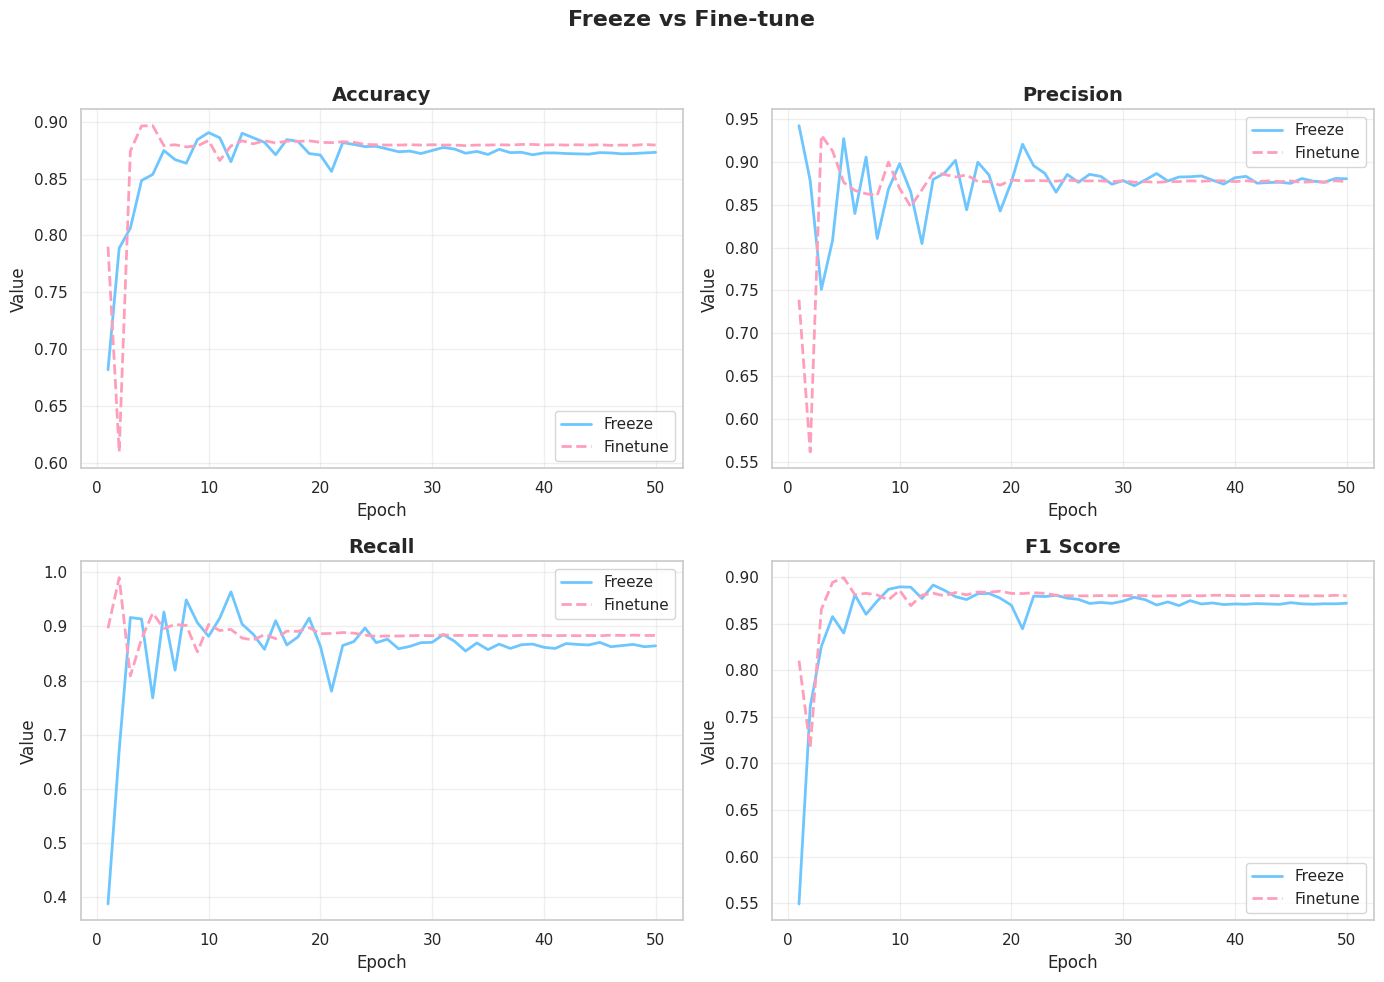

In [ ]:
# Seaborn
sns.set(style="whitegrid")

freeze_history = pd.read_csv("freeze_training_history2.csv")
finetune_history = pd.read_csv("finetune_training_history2.csv")

metrics = ["val_acc", "val_prec", "val_rec", "val_f1"]
metric_names = {
    "val_acc": "Accuracy",
    "val_prec": "Precision",
    "val_rec": "Recall",
    "val_f1": "F1 Score"
}

freeze_color = "#6EC6FF"
finetune_color = "#FF9EBB"

# 2×2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]

    # Freeze
    ax.plot(
        freeze_history["epoch"], freeze_history[metric],
        color=freeze_color, linestyle="-", linewidth=2, label="Freeze"
    )

    # Finetune
    ax.plot(
        finetune_history["epoch"], finetune_history[metric],
        color=finetune_color, linestyle="--", linewidth=2, label="Finetune"
    )

    ax.set_title(metric_names[metric], fontsize=14, fontweight="bold")
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Value", fontsize=12)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=11)

plt.suptitle("Freeze vs Fine-tune", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("freeze_vs_finetune_metrics.png", dpi=300, bbox_inches='tight')
plt.show()